# Project Summary Dashboard

Notebook tổng kết project RAG tư vấn thuốc/phân bón nông nghiệp.

Nội dung chính:

- Tóm tắt dữ liệu và pipeline.
- So sánh 8 cấu hình RAG đã benchmark.
- Chọn pipeline tốt nhất.
- Phân tích lỗi còn lại.
- Kết luận, hạn chế và hướng phát triển.

Notebook chỉ đọc kết quả có sẵn trong `results/generated_qa_30`, không tải model và không chạy GPU.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

RESULT_DIR = ROOT / "results" / "generated_qa_30"
QA_PATH = ROOT / "data" / "eval" / "generated_qa_30.json"
CHUNKS_PATH = ROOT / "data" / "chunks" / "chunks.json"
METADATA_SUMMARY_PATH = ROOT / "data" / "Thuoc_Metadata" / "_summary.json"

print("ROOT:", ROOT)
print("RESULT_DIR:", RESULT_DIR.relative_to(ROOT))

ROOT: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep
RESULT_DIR: results/generated_qa_30


## 1. Tóm tắt dữ liệu

Project dùng dữ liệu sản phẩm nông nghiệp đã được làm giàu thành metadata,
sau đó chia thành chunks để đưa vào embedding/Qdrant.

In [2]:
qa = json.loads(QA_PATH.read_text(encoding="utf-8"))
chunks = json.loads(CHUNKS_PATH.read_text(encoding="utf-8"))
metadata_summary = json.loads(METADATA_SUMMARY_PATH.read_text(encoding="utf-8"))

data_cards = pd.DataFrame([
    {"metric": "Số sản phẩm/record metadata", "value": metadata_summary.get("total_records")},
    {"metric": "Số nhóm sản phẩm", "value": len(metadata_summary.get("groups", {}))},
    {"metric": "Số chunks tri thức", "value": len(chunks)},
    {"metric": "Số sản phẩm có chunk", "value": len({item.get("product_id") for item in chunks})},
    {"metric": "Số câu hỏi đánh giá", "value": len(qa)},
    {"metric": "Số loại câu hỏi đánh giá", "value": len({item.get("type") for item in qa})},
])
display(data_cards)

group_df = pd.DataFrame(
    [{"loai": key, "records": value} for key, value in metadata_summary.get("groups", {}).items()]
).sort_values("records", ascending=False)
display(group_df)

,metric,value
0,Số sản phẩm/record metadata,500
1,Số nhóm sản phẩm,5
2,Số chunks tri thức,1000
3,Số sản phẩm có chunk,500
4,Số câu hỏi đánh giá,30
5,Số loại câu hỏi đánh giá,5


,loai,records
0,phan_bon,167
2,thuoc_tru_benh,117
4,thuoc_tru_sau,111
3,thuoc_tru_co,54
1,thuoc_kich_thich_sinh_truong,51


,type,count
0,goi_y_san_pham,6
1,cach_dung,6
2,gia,6
3,thanh_phan,6
4,an_toan,6


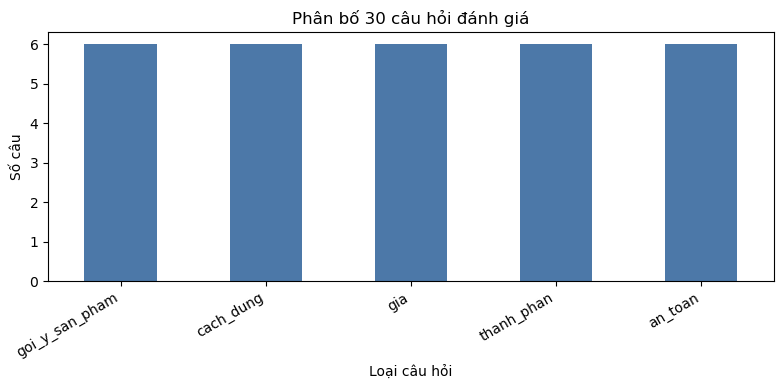

In [3]:
qa_type_counts = (
    pd.DataFrame(qa)["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)
display(qa_type_counts)

ax = qa_type_counts.plot.bar(x="type", y="count", legend=False, figsize=(8, 4), color="#4c78a8")
ax.set_title("Phân bố 30 câu hỏi đánh giá")
ax.set_xlabel("Loại câu hỏi")
ax.set_ylabel("Số câu")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 2. Kết quả benchmark 8 pipeline

Mỗi pipeline là một cặp LLM và embedding:

- LLM: `qwen25_3b`, `qwen3_4b`
- Embedding: `bge_m3`, `multilingual_e5_base`, `sup_simcse`, `vietnamese_bi_encoder`

In [4]:
rows = []
eval_items = []

for path in sorted(RESULT_DIR.glob("eval_*.json")):
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = data["summary"]
    pipeline = path.stem.replace("eval_", "")
    llm, embedding = pipeline.split("__", 1)
    total = summary["total"]
    passed = summary["passed"]
    rows.append({
        "pipeline": pipeline,
        "llm": llm,
        "embedding": embedding,
        "total": total,
        "passed": passed,
        "failed": summary.get("failed", total - passed),
        "pass_rate": summary["pass_rate"],
        "retrieval_hit_rate": summary["retrieval_hit_rate"],
        "answer_keyword_hit_rate": summary["answer_keyword_hit_rate"],
        "answer_product_name_hit_rate": summary["answer_product_name_hit_rate"],
    })
    for item in data.get("items", []):
        item = dict(item)
        item["pipeline"] = pipeline
        item["llm"] = llm
        item["embedding"] = embedding
        eval_items.append(item)

summary_df = pd.DataFrame(rows).sort_values("pass_rate", ascending=False)
eval_df = pd.DataFrame(eval_items)
if "retrieval_hit" not in eval_df.columns and "retrieval_product_hit" in eval_df.columns:
    eval_df["retrieval_hit"] = eval_df["retrieval_product_hit"]

display(summary_df)

,pipeline,llm,embedding,total,passed,failed,pass_rate,retrieval_hit_rate,answer_keyword_hit_rate,answer_product_name_hit_rate
4,qwen3_4b__bge_m3,qwen3_4b,bge_m3,30,28,2,0.9333,0.9333,0.9667,0.9333
0,qwen25_3b__bge_m3,qwen25_3b,bge_m3,30,26,4,0.8667,0.9333,0.9000,0.8667
5,qwen3_4b__multilingual_e5_base,qwen3_4b,multilingual_e5_base,30,22,8,0.7333,0.7333,0.9333,0.8333
1,qwen25_3b__multilingual_e5_base,qwen25_3b,multilingual_e5_base,30,20,10,0.6667,0.7333,0.8333,0.7333
7,qwen3_4b__vietnamese_bi_encoder,qwen3_4b,vietnamese_bi_encoder,30,12,18,0.4000,0.4000,0.8000,0.7667
3,qwen25_3b__vietnamese_bi_encoder,qwen25_3b,vietnamese_bi_encoder,30,11,19,0.3667,0.4000,0.8000,0.7000
2,qwen25_3b__sup_simcse,qwen25_3b,sup_simcse,30,4,26,0.1333,0.1333,0.8667,0.7333
6,qwen3_4b__sup_simcse,qwen3_4b,sup_simcse,30,4,26,0.1333,0.1333,0.8333,0.7667


In [5]:
best = summary_df.iloc[0]
second = summary_df.iloc[1]
worst = summary_df.iloc[-1]

display(Markdown(f'''
### Kết luận nhanh

- Pipeline tốt nhất: **{best.pipeline}**
- Pass rate: **{best.pass_rate:.2%}** ({int(best.passed)}/{int(best.total)})
- Retrieval hit rate: **{best.retrieval_hit_rate:.2%}**
- Answer keyword hit rate: **{best.answer_keyword_hit_rate:.2%}**
- Answer product name hit rate: **{best.answer_product_name_hit_rate:.2%}**

Pipeline đứng thứ hai: **{second.pipeline}** với pass rate **{second.pass_rate:.2%}**.

Pipeline yếu nhất: **{worst.pipeline}** với pass rate **{worst.pass_rate:.2%}**.
'''))


### Kết luận nhanh

- Pipeline tốt nhất: **qwen3_4b__bge_m3**
- Pass rate: **93.33%** (28/30)
- Retrieval hit rate: **93.33%**
- Answer keyword hit rate: **96.67%**
- Answer product name hit rate: **93.33%**

Pipeline đứng thứ hai: **qwen25_3b__bge_m3** với pass rate **86.67%**.

Pipeline yếu nhất: **qwen3_4b__sup_simcse** với pass rate **13.33%**.


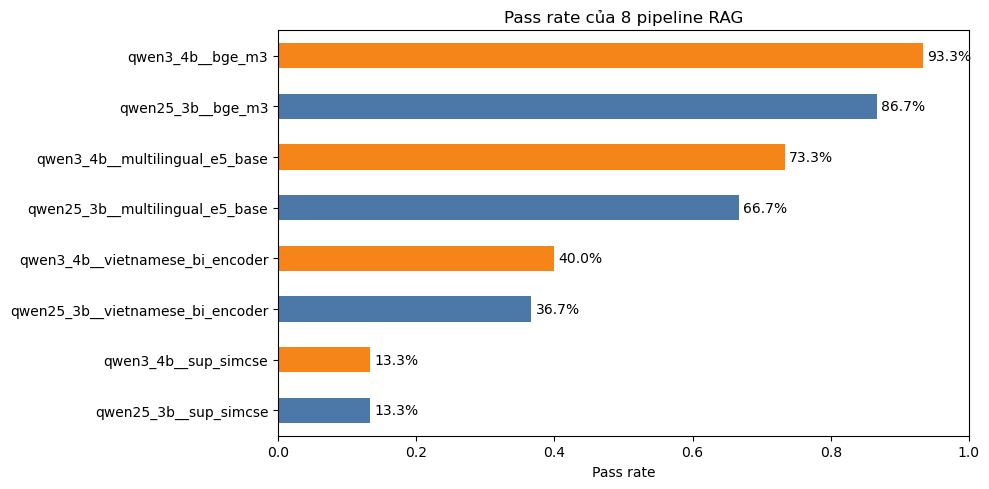

In [6]:
plot_df = summary_df.sort_values("pass_rate")
colors = ["#4c78a8" if llm == "qwen25_3b" else "#f58518" for llm in plot_df["llm"]]

ax = plot_df.plot.barh(
    x="pipeline",
    y="pass_rate",
    legend=False,
    figsize=(10, 5),
    color=colors,
)
ax.set_title("Pass rate của 8 pipeline RAG")
ax.set_xlabel("Pass rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in plot_df["pass_rate"]], padding=3)
plt.tight_layout()
plt.show()

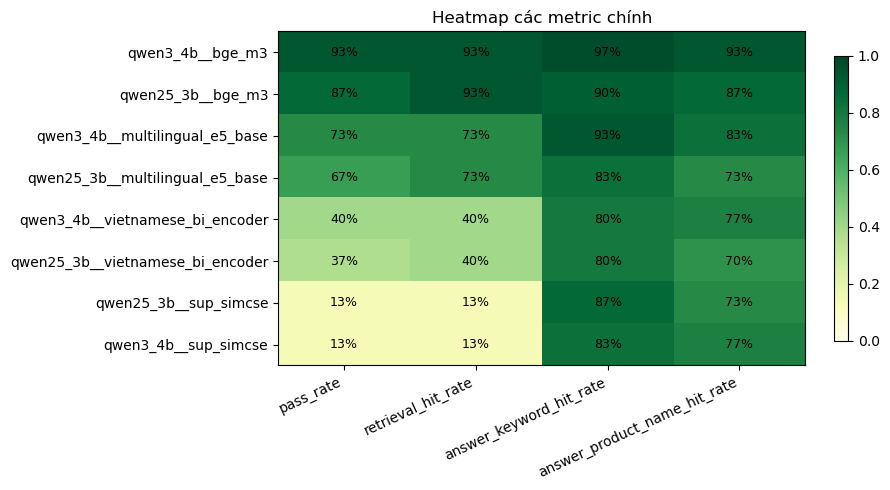

In [7]:
metrics = [
    "pass_rate",
    "retrieval_hit_rate",
    "answer_keyword_hit_rate",
    "answer_product_name_hit_rate",
]
heatmap_df = summary_df.set_index("pipeline")[metrics].sort_values("pass_rate", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heatmap_df.values, aspect="auto", vmin=0, vmax=1, cmap="YlGn")
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, rotation=25, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Heatmap các metric chính")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(j, i, f"{heatmap_df.iloc[i, j]:.0%}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

## 2.1. So sánh tốc độ trả lời câu hỏi

Bảng dưới đây lấy từ thư mục `results/rag_benchmark`. Mỗi dòng là một pipeline RAG, gồm thời gian truy xuất context, thời gian LLM sinh câu trả lời và tổng thời gian trung bình trên bộ benchmark. Bảng được sắp xếp theo `Total TB (s)` tăng dần.

| Pipeline | LLM | Embedding | Số câu | Retrieval TB (s) | Generation TB (s) | Total TB (s) | Top1 score TB |
| --- | --- | --- | --- | --- | --- | --- | --- |
| qwen25_3b__sup_simcse | qwen25_3b | sup_simcse | 18 | 0.0209 | 10.134 | 10.155 | 0.7792 |
| qwen25_3b__vietnamese_bi_encoder | qwen25_3b | vietnamese_bi_encoder | 18 | 0.0207 | 10.659 | 10.680 | 0.4770 |
| qwen25_3b__multilingual_e5_base | qwen25_3b | multilingual_e5_base | 18 | 0.0218 | 10.830 | 10.852 | 0.8714 |
| qwen25_3b__bge_m3 | qwen25_3b | bge_m3 | 18 | 0.0281 | 11.376 | 11.404 | 0.7007 |
| qwen3_4b__vietnamese_bi_encoder | qwen3_4b | vietnamese_bi_encoder | 18 | 0.0273 | 16.375 | 16.403 | 0.4770 |
| qwen3_4b__sup_simcse | qwen3_4b | sup_simcse | 18 | 0.0227 | 16.389 | 16.411 | 0.7792 |
| qwen3_4b__multilingual_e5_base | qwen3_4b | multilingual_e5_base | 18 | 0.0296 | 20.761 | 20.790 | 0.8714 |
| qwen3_4b__bge_m3 | qwen3_4b | bge_m3 | 18 | 0.0321 | 21.609 | 21.641 | 0.7007 |

Nhận xét nhanh: thời gian retrieval chỉ ở mức vài chục mili-giây, trong khi generation chiếm gần như toàn bộ độ trễ. Vì vậy khi triển khai thật, phần cần tối ưu nhiều nhất là LLM, thiết bị chạy và giới hạn `max_new_tokens`.


In [ ]:
RAG_RESULT_DIR = ROOT / "results" / "rag_benchmark"

latency_rows = []
for path in sorted(RAG_RESULT_DIR.glob("*.json")):
    items = json.loads(path.read_text(encoding="utf-8"))
    retrieval_times = []
    generation_times = []
    total_times = []
    top1_scores = []

    for item in items:
        latency = item.get("latency", {})
        if isinstance(latency.get("retrieval_seconds"), (int, float)):
            retrieval_times.append(latency["retrieval_seconds"])
        if isinstance(latency.get("generation_seconds"), (int, float)):
            generation_times.append(latency["generation_seconds"])
        if isinstance(latency.get("total_seconds"), (int, float)):
            total_times.append(latency["total_seconds"])

        retrieved_chunks = item.get("retrieved_chunks", [])
        if retrieved_chunks and isinstance(retrieved_chunks[0].get("score"), (int, float)):
            top1_scores.append(retrieved_chunks[0]["score"])

    def mean_or_none(values):
        return sum(values) / len(values) if values else None

    pipeline = path.stem
    llm, embedding = pipeline.split("__", 1)
    latency_rows.append({
        "pipeline": pipeline,
        "llm": llm,
        "embedding": embedding,
        "so_cau": len(items),
        "retrieval_tb_s": mean_or_none(retrieval_times),
        "generation_tb_s": mean_or_none(generation_times),
        "total_tb_s": mean_or_none(total_times),
        "top1_score_tb": mean_or_none(top1_scores),
    })

latency_df = pd.DataFrame(latency_rows).sort_values("total_tb_s")
display(latency_df)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_latency = latency_df.sort_values("total_tb_s")
ax.barh(plot_latency["pipeline"], plot_latency["total_tb_s"], color="#2f6f9f")
ax.set_xlabel("Thời gian trả lời trung bình (giây)")
ax.set_ylabel("Pipeline")
ax.set_title("So sánh tốc độ trả lời trung bình của 8 pipeline RAG")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. So sánh LLM và embedding

Phần này tách ảnh hưởng của model sinh câu trả lời và model embedding.

In [8]:
llm_compare = (
    summary_df.groupby("llm")
    .agg(
        avg_pass_rate=("pass_rate", "mean"),
        avg_retrieval_hit_rate=("retrieval_hit_rate", "mean"),
        best_pass_rate=("pass_rate", "max"),
    )
    .sort_values("avg_pass_rate", ascending=False)
)

embedding_compare = (
    summary_df.groupby("embedding")
    .agg(
        avg_pass_rate=("pass_rate", "mean"),
        avg_retrieval_hit_rate=("retrieval_hit_rate", "mean"),
        best_pass_rate=("pass_rate", "max"),
    )
    .sort_values("avg_pass_rate", ascending=False)
)

display(llm_compare.style.format("{:.2%}"))
display(embedding_compare.style.format("{:.2%}"))

,avg_pass_rate,avg_retrieval_hit_rate,best_pass_rate
llm,,,
qwen3_4b,55.00%,55.00%,93.33%
qwen25_3b,50.83%,55.00%,86.67%


,avg_pass_rate,avg_retrieval_hit_rate,best_pass_rate
embedding,,,
bge_m3,90.00%,93.33%,93.33%
multilingual_e5_base,70.00%,73.33%,73.33%
vietnamese_bi_encoder,38.34%,40.00%,40.00%
sup_simcse,13.33%,13.33%,13.33%


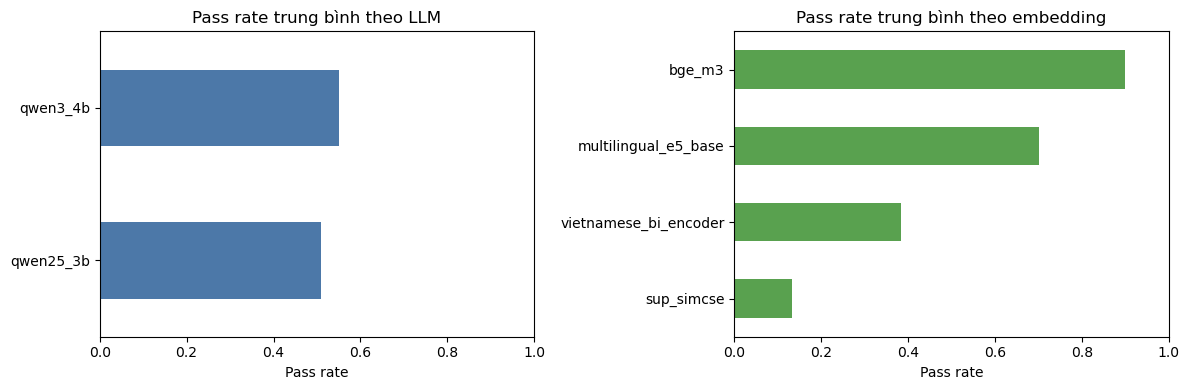

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

llm_compare.sort_values("avg_pass_rate").plot.barh(
    y="avg_pass_rate",
    legend=False,
    ax=axes[0],
    color="#4c78a8",
)
axes[0].set_title("Pass rate trung bình theo LLM")
axes[0].set_xlabel("Pass rate")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 1)

embedding_compare.sort_values("avg_pass_rate").plot.barh(
    y="avg_pass_rate",
    legend=False,
    ax=axes[1],
    color="#59a14f",
)
axes[1].set_title("Pass rate trung bình theo embedding")
axes[1].set_xlabel("Pass rate")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 4. Lỗi còn lại của pipeline tốt nhất

Xem pipeline tốt nhất còn sai những câu nào để biết cần cải thiện retrieval, prompt hay dữ liệu.

In [10]:
best_pipeline = best.pipeline
best_items = eval_df[eval_df["pipeline"] == best_pipeline].copy()
fail_df = best_items[~best_items["passed"]].copy()

print("Best pipeline:", best_pipeline)
print("Số câu sai:", len(fail_df))

if len(fail_df):
    display(fail_df[[
        "question_id",
        "type",
        "question",
        "retrieval_hit",
        "answer_keyword_hit",
        "answer_product_name_hit",
    ]])
else:
    print("Pipeline tốt nhất không có câu sai.")

Best pipeline: qwen3_4b__bge_m3
Số câu sai: 2


,question_id,type,question,retrieval_hit,answer_keyword_hit,answer_product_name_hit
125,qa006,goi_y_san_pham,"Rau màu có biểu hiện Rễ ít, đất chai cứng, cây...",False,True,False
140,qa021,goi_y_san_pham,"Rau màu có biểu hiện Sinh trưởng chậm, bộ rễ k...",False,False,False


,type,total,passed,retrieval_hit_rate,keyword_hit_rate,product_name_hit_rate,pass_rate
3,goi_y_san_pham,6,4,0.666667,0.833333,0.666667,0.666667
0,an_toan,6,6,1.000000,1.000000,1.000000,1.000000
1,cach_dung,6,6,1.000000,1.000000,1.000000,1.000000
2,gia,6,6,1.000000,1.000000,1.000000,1.000000
4,thanh_phan,6,6,1.000000,1.000000,1.000000,1.000000


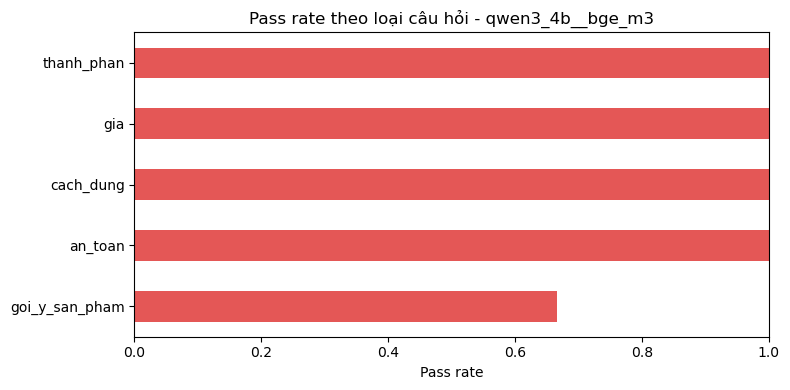

In [11]:
type_perf = (
    best_items.groupby("type")
    .agg(
        total=("question_id", "count"),
        passed=("passed", "sum"),
        retrieval_hit_rate=("retrieval_hit", "mean"),
        keyword_hit_rate=("answer_keyword_hit", "mean"),
        product_name_hit_rate=("answer_product_name_hit", "mean"),
    )
    .reset_index()
)
type_perf["pass_rate"] = type_perf["passed"] / type_perf["total"]
type_perf = type_perf.sort_values("pass_rate")
display(type_perf)

ax = type_perf.plot.barh(x="type", y="pass_rate", legend=False, figsize=(8, 4), color="#e45756")
ax.set_title(f"Pass rate theo loại câu hỏi - {best_pipeline}")
ax.set_xlabel("Pass rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 5. Ví dụ một câu trả lời RAG

Ví dụ này cho thấy câu hỏi, câu trả lời và các chunk được truy xuất làm context.

In [12]:
selected_question_id = "qa001"
raw_path = RESULT_DIR / f"{best_pipeline}.json"
raw_data = json.loads(raw_path.read_text(encoding="utf-8"))
raw_item = next(item for item in raw_data if item["question_id"] == selected_question_id)

print("QUESTION:")
print(raw_item["question"])
print("\nANSWER:")
print(raw_item["answer"])

top_chunks = pd.DataFrame(raw_item["retrieved_chunks"])
display(top_chunks[["rank", "score", "product_id", "ten_san_pham", "text"]].head(5))

QUESTION:
Cây ăn trái có biểu hiện Hoa khô, rụng hàng loạt, trái non dễ rụng. Nên dùng sản phẩm nào và vì sao?

ANSWER:
1. Chẩn đoán khả năng  
Cây ăn trái có biểu hiện hoa khô, rụng hàng loạt, trái non dễ rụng có thể do thiếu vi lượng Kẽm và Bo trong giai đoạn phân hóa mầm hoa.

2. Sản phẩm gợi ý  
KẼM BORON 50.000ppm

3. Lý do phù hợp  
Sản phẩm KẼM BORON 50.000ppm có thành phần chứa 50.000ppm Kẽm và 50.000ppm Bo, giúp tăng khả năng thụ phấn, đậu trái và hạn chế rụng hoa, trái non – phù hợp với triệu chứng hoa khô, rụng hàng loạt và trái non dễ rụng.

4. Cách dùng tóm tắt  
Pha 500g sản phẩm cho 200–250 lít nước, phun đều hai mặt lá.

5. Lưu ý an toàn  
Không pha chung với thuốc có tính kiềm mạnh. Bảo quản nơi khô ráo.


,rank,score,product_id,ten_san_pham,text
0,1,0.704584,sp372,ANTI DROP FLOWER FRUIT,Sản phẩm: ANTI DROP FLOWER FRUIT Loại: thuoc_k...
1,2,0.695642,sp404,NPK 6-20-30 + BO,Sản phẩm: NPK 6-20-30 + BO Loại: phan_bon Rule...
2,3,0.694210,sp306,NPK 8-24-24 + BO,Sản phẩm: NPK 8-24-24 + BO Loại: phan_bon Rule...
3,4,0.683747,sp179,CHỐNG RỤNG HOA TRÁI NAA + BO,Sản phẩm: CHỐNG RỤNG HOA TRÁI NAA + BO Loại: t...
4,5,0.683292,sp1,KẼM BORON 50.000ppm,Sản phẩm: KẼM BORON 50.000ppm Loại: phan_bon R...


## 6. Vai trò Redis memory

Redis không phải nguồn kiến thức sản phẩm. Redis chỉ lưu lịch sử hội thoại ngắn hạn theo `session_id`.

- Qdrant: nhớ tri thức sản phẩm.
- Redis: nhớ người dùng vừa hỏi gì trong cuộc trò chuyện.
- LLM: sinh câu trả lời dựa trên context từ Qdrant và lịch sử từ Redis.

In [13]:
display(pd.DataFrame([
    {
        "component": "Qdrant",
        "role": "Lưu vector tri thức sản phẩm để truy xuất top-k",
        "example": "thuoc_metadata_bge_m3",
    },
    {
        "component": "Redis",
        "role": "Lưu lịch sử hội thoại theo session",
        "example": "rag_chat:demo-memory-1:messages",
    },
    {
        "component": "LLM",
        "role": "Sinh câu trả lời từ context + lịch sử",
        "example": "qwen3_4b",
    },
]))

,component,role,example
0,Qdrant,Lưu vector tri thức sản phẩm để truy xuất top-k,thuoc_metadata_bge_m3
1,Redis,Lưu lịch sử hội thoại theo session,rag_chat:demo-memory-1:messages
2,LLM,Sinh câu trả lời từ context + lịch sử,qwen3_4b


## 7. Kết luận và hướng phát triển

Kết quả hiện tại cho thấy pipeline **qwen3_4b + bge_m3** là lựa chọn tốt nhất cho demo.

Hạn chế:

- Bộ test mới có 30 câu, cần mở rộng thêm.
- Cần kiểm tra thủ công các câu có giá, liều lượng, an toàn.
- Nếu retrieval sai sản phẩm, LLM vẫn có thể trả lời nghe hợp lý nhưng không đúng dữ liệu.

Hướng phát triển:

- Mở rộng bộ câu hỏi theo nhiều cây trồng/tình huống thực tế.
- Tối ưu prompt để giảm hallucination.
- Thêm kiểm tra câu trả lời dựa trên evidence từ chunk.
- Đóng gói demo chatbot dùng Redis + Qdrant + pipeline tốt nhất.

In [14]:
conclusion = {
    "recommended_pipeline": best_pipeline,
    "pass_rate": round(float(best.pass_rate), 4),
    "retrieval_hit_rate": round(float(best.retrieval_hit_rate), 4),
    "why": "Pipeline có pass rate cao nhất và retrieval hit rate tốt.",
    "main_limitation": "Bộ đánh giá còn nhỏ, cần mở rộng và kiểm tra thủ công sâu hơn.",
    "next_steps": [
        "Mở rộng benchmark QA.",
        "Tối ưu prompt chống bịa thông tin.",
        "Thêm đánh giá evidence từ retrieved chunks.",
        "Đóng gói chatbot demo với Redis memory.",
    ],
}
display(conclusion)

{'recommended_pipeline': 'qwen3_4b__bge_m3',
 'pass_rate': 0.9333,
 'retrieval_hit_rate': 0.9333,
 'why': 'Pipeline có pass rate cao nhất và retrieval hit rate tốt.',
 'main_limitation': 'Bộ đánh giá còn nhỏ, cần mở rộng và kiểm tra thủ công sâu hơn.',
 'next_steps': ['Mở rộng benchmark QA.',
  'Tối ưu prompt chống bịa thông tin.',
  'Thêm đánh giá evidence từ retrieved chunks.',
  'Đóng gói chatbot demo với Redis memory.']}